In [11]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns
from sklearn .model_selection import train_test_split



In [13]:
hrt=pd.read_csv('heart.csv')
hrt.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40.0,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49.0,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37.0,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48.0,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54.0,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
hrt.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,914.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.553611,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.424972,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [16]:
hrt.isna().sum()

Age               4
Sex               3
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [19]:
gender=hrt['Sex'].value_counts()
gender

Sex
M    723
F    192
Name: count, dtype: int64

In [21]:
from sklearn .preprocessing import LabelEncoder

In [23]:
encode= LabelEncoder()
hrt['Sex']=encode.fit_transform(hrt['Sex'])
hrt.ChestPainType =encode.fit_transform(hrt.ChestPainType )
hrt.RestingECG   =encode.fit_transform(hrt.RestingECG )
hrt.ExerciseAngina =encode.fit_transform(hrt.ExerciseAngina  )
hrt.ST_Slope  =encode.fit_transform(hrt.ST_Slope)

In [25]:
x=hrt.iloc[: , :-1]
y=hrt.HeartDisease

In [89]:
x_tr,x_te,y_tr,y_te=train_test_split(X,y,test_size=0.2)

In [91]:
from sklearn.linear_model import LogisticRegression


In [93]:
model=LogisticRegression()
model.fit(x_tr,y_tr)
y_pr=model.predict(x_te)

C:\Users\anitr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [95]:
from sklearn. metrics import accuracy_score
accuracy_score(y_te,y_pr)*100

86.95652173913044

In [45]:
x_te.shape

(184, 11)

In [47]:
hrt.shape

(918, 12)

In [49]:
hrt['Age'].fillna(np.mean(hrt['Age']),inplace=True)

C:\Users\anitr\AppData\Local\Temp\ipykernel_10232\3830524993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hrt['Age'].fillna(np.mean(hrt['Age']),inplace=True)


In [51]:
hrt['Sex'].fillna('M',inplace=True)

C:\Users\anitr\AppData\Local\Temp\ipykernel_10232\97002793.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hrt['Sex'].fillna('M',inplace=True)


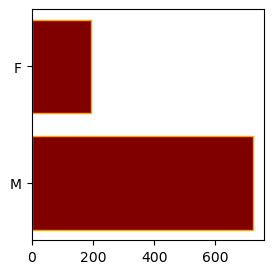

In [53]:
fig=plt.figure(figsize=(3,3))
plt.barh(gender.index,gender.values,color='Maroon',edgecolor='orange')
plt.show()


In [54]:
chestpain=hrt.ChestPainType.value_counts()

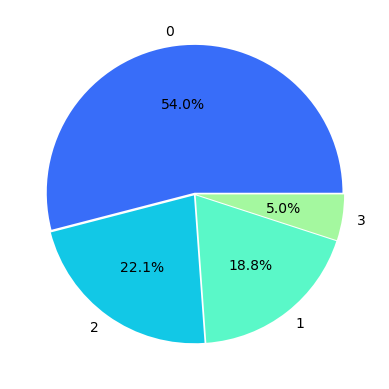

In [55]:
sns.set_palette('rainbow')
plt.pie(chestpain.values,labels=chestpain.index,autopct='%0.1f%%',explode=[0.01,0.01,0.01,0.01])
plt.show()

In [56]:
hrt.groupby('HeartDisease')['Cholesterol'].mean()

HeartDisease
0    227.121951
1    175.940945
Name: Cholesterol, dtype: float64

In [59]:
## applying decision tree classification algorithm
from sklearn.tree import DecisionTreeClassifier

In [63]:
depth=[1,2,3,4,5,6,7,8,9,10,11,12]
accuracies=[]


In [64]:
for i in depth:
    model=DecisionTreeClassifier(max_depth=i)
    model.fit(x_tr,y_tr)
    y_pred=model.predict(x_te)
    accuracies.append(accuracy_score(y_te,y_pred)*100)

In [66]:
for i in range(len(depth)):
    print(f'accuracy of decision tree with depth{depth[i]} is {accuracies[i]}')
    

accuracy of decision tree with depth1 is 80.97826086956522
accuracy of decision tree with depth2 is 83.15217391304348
accuracy of decision tree with depth3 is 84.78260869565217
accuracy of decision tree with depth4 is 82.6086956521739
accuracy of decision tree with depth5 is 80.43478260869566
accuracy of decision tree with depth6 is 82.06521739130434
accuracy of decision tree with depth7 is 76.63043478260869
accuracy of decision tree with depth8 is 78.80434782608695
accuracy of decision tree with depth9 is 82.06521739130434
accuracy of decision tree with depth10 is 80.43478260869566
accuracy of decision tree with depth11 is 77.71739130434783
accuracy of decision tree with depth12 is 78.80434782608695


In [69]:
depth=[1,2,3,4,5,6,7,8,9,10,11,12]
accuracies=[]
for i in depth:
    model=DecisionTreeClassifier(criterion='gini',max_depth=i)
    model.fit(x_tr,y_tr)
    y_pr=model.predict(x_te)
    accuracies.append(accuracy_score(y_te,y_pr)*100)

In [71]:
for i in range(len(depth)):
    print(f'accuracy of decision tree with depth{depth[i]} is {accuracies[i]}')
    

accuracy of decision tree with depth1 is 80.97826086956522
accuracy of decision tree with depth2 is 83.15217391304348
accuracy of decision tree with depth3 is 84.78260869565217
accuracy of decision tree with depth4 is 83.69565217391305
accuracy of decision tree with depth5 is 80.43478260869566
accuracy of decision tree with depth6 is 82.06521739130434
accuracy of decision tree with depth7 is 76.63043478260869
accuracy of decision tree with depth8 is 78.26086956521739
accuracy of decision tree with depth9 is 79.8913043478261
accuracy of decision tree with depth10 is 79.34782608695652
accuracy of decision tree with depth11 is 79.8913043478261
accuracy of decision tree with depth12 is 79.34782608695652


## applying KNN algorithm

In [74]:
X=hrt.iloc[:,:-1]
Y=hrt.iloc[:,-1]

In [76]:
from sklearn.model_selection import train_test_split

In [78]:
X_tr,X_te,Y_tr,Y_te=train_test_split(X,Y,test_size=0.2)

In [80]:
from sklearn.linear_model import LogisticRegression


In [82]:
model= LogisticRegression()
model.fit(X_tr,Y_tr)

C:\Users\anitr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [84]:
from sklearn.neighbors import KNeighborsClassifier

In [103]:
k=[1,2,3,4,5,6,7,8,9,10]
accus=[]
for i in k:
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(X_tr,Y_tr)
    y_pred=model.predict(X_te)
    accus.append(accuracy_score(Y_te,y_pred)*100)

In [105]:
accus

[65.21739130434783,
 64.13043478260869,
 64.67391304347827,
 66.84782608695652,
 69.56521739130434,
 66.30434782608695,
 67.3913043478261,
 64.67391304347827,
 63.04347826086957,
 63.04347826086957]

## Naive Bayas

In [157]:
from sklearn.naive_bayes import GaussianNB


In [159]:
model= GaussianNB()
model.fit(X_tr,Y_tr)
y_pred=model.predict(x_te)


In [153]:
accuracy_score(y_te,y_pred)*100

82.6086956521739